In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

In [ ]:
color1 = cm.inferno_r(np.linspace(.4, .8, 30))
color2 = cm.magma_r(np.linspace(.4, .8, 30))

In [2]:
# TODO:

# km. min = - 870.30

In [3]:
df = pd.read_csv('data-treatment.csv', )

C:\Users\RAFAEL\AppData\Local\Temp\ipykernel_7916\3540814682.py:1: DtypeWarning: Columns (0: km) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data-treatment.csv', )


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1562034 entries, 0 to 1562033
Data columns (total 30 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   data_inversa            1562034 non-null  str   
 1   dia_semana              1562034 non-null  str   
 2   horario                 1562034 non-null  str   
 3   uf                      1562034 non-null  str   
 4   br                      1562034 non-null  int64 
 5   km                      1562034 non-null  object
 6   municipio               1562034 non-null  str   
 7   causa_acidente          1562034 non-null  str   
 8   tipo_acidente           1562034 non-null  str   
 9   classificacao_acidente  1562034 non-null  str   
 10  fase_dia                1562034 non-null  str   
 11  sentido_via             1562034 non-null  str   
 12  condicao_metereologica  1562034 non-null  str   
 13  tipo_pista              1562034 non-null  str   
 14  tracado_via             15620

In [5]:
df['br'] = df['br'].astype(str)
df['km'] = df['km'].astype(str)
df['ano'] = df['ano'].astype(str)

In [6]:
df.describe().round(2)

,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,mes,horas,dia
count,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00
mean,2.16,0.05,0.45,0.16,1.41,0.09,0.61,1.74,6.56,13.05,15.64
std,1.56,0.28,0.98,0.56,1.23,0.38,1.19,0.72,3.49,5.84,8.76
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00
25%,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,4.00,8.00,8.00
50%,2.00,0.00,0.00,0.00,1.00,0.00,0.00,2.00,7.00,14.00,16.00
75%,2.00,0.00,1.00,0.00,2.00,0.00,1.00,2.00,10.00,18.00,23.00
max,248.00,33.00,52.00,222.00,99.00,86.00,239.00,25.00,12.00,23.00,31.00


In [7]:
# Deixar a função com argumentos adicionais para personalizar mais

def plot_bar(lista, freq_values):
    # TODO: Adicionar docstring + valores opcionais
    fig, ax = plt.subplots(figsize=(9,3))

    ax.bar(lista, freq_values, edgecolor='black', linewidth=0.7)

    ax.set(xlim=(0, 8), xticks=np.arange(-1, len(lista)+1))

    plt.show()

- Quais são os 10 estados com maior número de acidentes registrados?

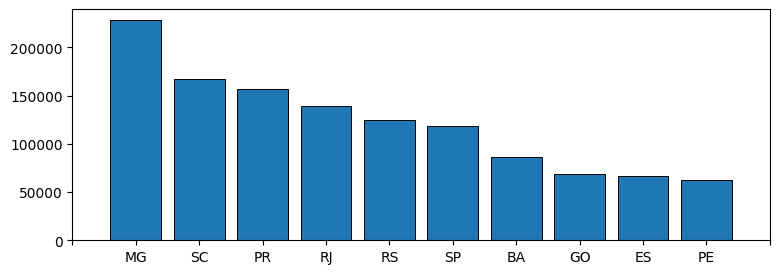

In [8]:
analysis = df.groupby(['uf'])['uf'].count().sort_values(ascending=False)
plot_bar(analysis.iloc[:10].index,analysis.iloc[:10].values)

In [9]:
df.columns

Index(['data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio',
       'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia',
       'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via',
       'uso_solo', 'ano', 'pessoas', 'mortos', 'feridos_leves',
       'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'mes',
       'ano_mes', 'horas', 'dia', 'regiao'],
      dtype='str')

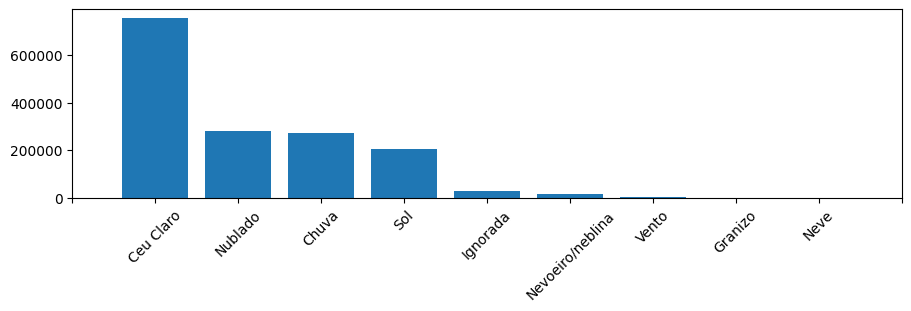

In [10]:
a = df.groupby(['condicao_metereologica'])['condicao_metereologica'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9,3), layout="constrained")

ax.bar(a.index, a.values, linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(-1, len(a.index)+1))

ax.tick_params("x", rotation=45)

plt.show()

In [11]:
a = df.groupby(['condicao_metereologica'])['condicao_metereologica'].count().sort_values(ascending=False)


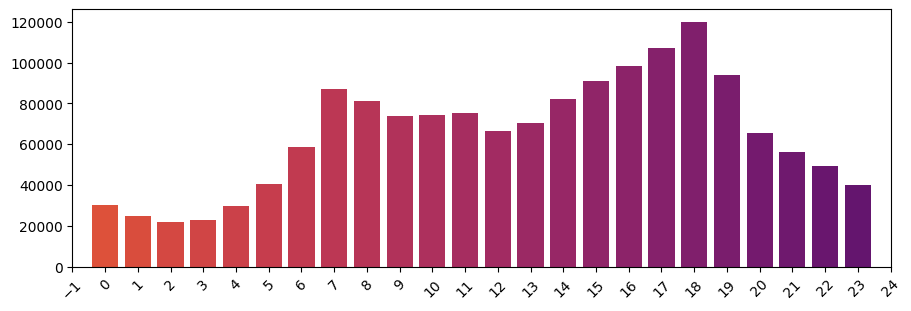

In [12]:
a= df.groupby(['horas'])['horas'].count()

color = cm.inferno_r(np.linspace(.4, .8, 30))

fig, ax = plt.subplots(figsize=(9,3), layout="constrained")

ax.bar(a.index, a.values, linewidth=0.7, color = color)

ax.set(xlim=(0, 8), xticks=np.arange(-1, len(a.index)+1))

ax.tick_params("x", rotation=45)

plt.show()

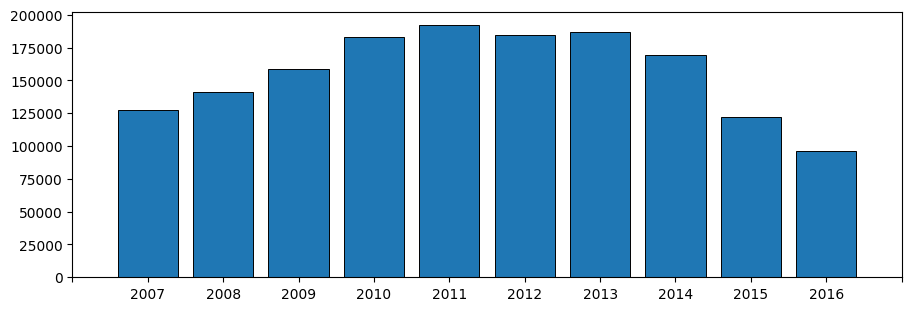

In [13]:
a = df.groupby(['ano'])['ano'].count()

fig, ax = plt.subplots(figsize=(9,3), layout="constrained")

ax.bar(a.index.astype(str), a.values, edgecolor='black', linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(-1, len(a.index)+1))

plt.show()

In [14]:
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

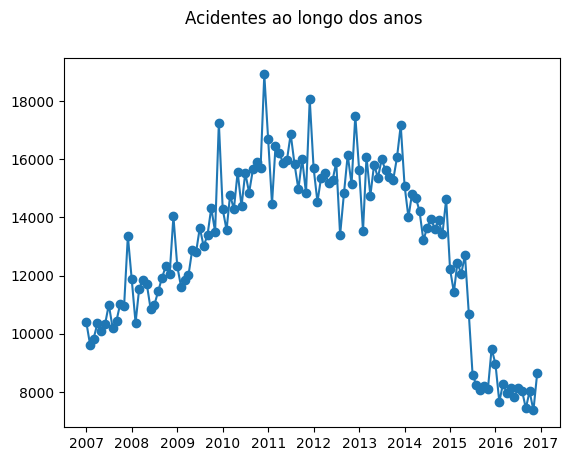

In [15]:
a = df.groupby(['ano_mes'])['ano_mes'].count()

fig = plt.figure()

fig.suptitle('Acidentes ao longo dos anos')

ax = fig.add_subplot()

ax.plot(a.index, a.values, '-o')

#ax.set(xticks=np.arange(1, len(lista_series)+1))

plt.show()

- Qual é a distribuição de acidentes por dia da semana?

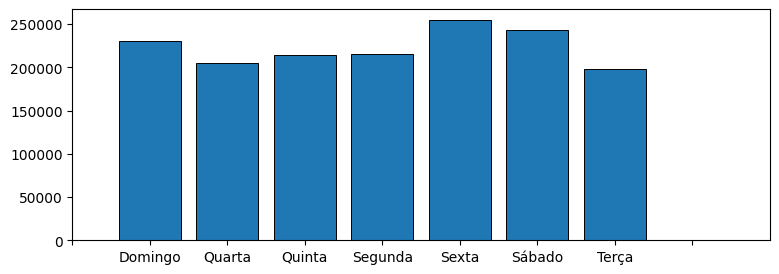

In [16]:
a = df.groupby(['dia_semana'])['dia_semana'].count()
plot_bar(a.index, a.values)

- Quais meses do ano concentram mais acidentes e mortes?

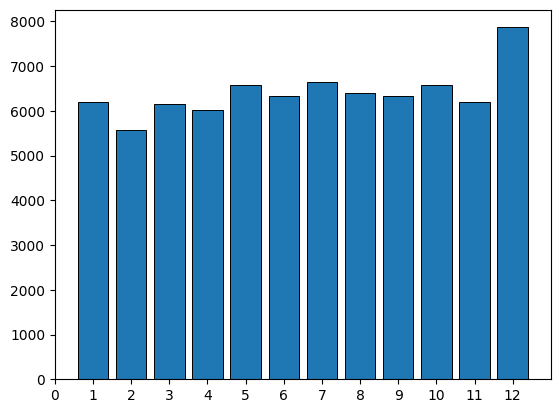

In [17]:
a = df.groupby(['mes'])['mortos'].sum()

fig, ax = plt.subplots()

ax.bar(a.index, a.values, edgecolor='blacK', linewidth=0.7)

ax.set(xlim = (0, len(a.index)+1), xticks=np.arange(0, len(a.index)+1))

plt.show()


- Existe interação entre dia da semana e horário que eleva a gravidade dos acidentes?

In [18]:
a = df.groupby(['dia_semana', 'horas', 'classificacao_acidente'])[['classificacao_acidente']].count()
a

classificacao_acidente
dia_semana horas classificacao_acidente                        
Domingo    0     Com Vítimas Fatais                         491
                 Com Vítimas Feridas                       2763
                 Ignorado                                   125
                 Sem Vítimas                               2607
           1     Com Vítimas Fatais                         417
...                                                         ...
Terça      22    Sem Vítimas                               3040
           23    Com Vítimas Fatais                         272
                 Com Vítimas Feridas                       1704
                 Ignorado                                    52
                 Sem Vítimas                               2470

[672 rows x 1 columns]

- A redução de acidentes ao longo dos anos é uniforme entre estados ou concentrada em alguns?

In [19]:
# Aqui eu posso reaproveitar aquele lá, mas acho que ficaria mt poluído, vou procurar outro por enquanto

df.groupby(['uf', 'ano'])['ano'].count()

uf  ano 
AC  2007     324
    2008     353
    2009     365
    2010     462
    2011     518
            ... 
TO  2012    1179
    2013    1279
    2014    1301
    2015     872
    2016     836
Name: ano, Length: 270, dtype: int64

- Quais rodovias federais concentram o maior número de mortes?

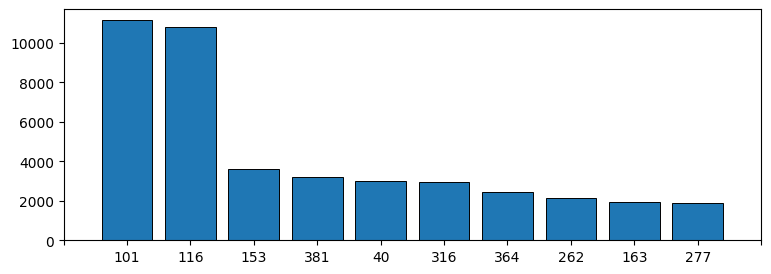

In [20]:
# porra, e eu fazendo tudo na mão, eu esqueci completamente do pandas
# MEUDEUS É MT MAIS FÁCIL CARA, tipo, aqui já tá tudo ordenado, nem me preocupar eu tenho

plot_bar((df.groupby(['br']) # juntamos por estradas
          ['mortos'].sum()) # aplicamos uma soma da coluna que diz respeito aos falecidos no acidente
          .sort_values(ascending=False) # ordenamos para pegar os maiores
          .iloc[:10].index.astype(str) # aqui estou passando apenas o índice, já que fiz a função para ser assim mesmo
          # aqui é p passar os valores realmente
          , (df.groupby(['br'])['mortos'].sum()).sort_values(ascending=False).iloc[:10].values)

- Quais municípios têm a maior taxa de mortalidade por acidente?

In [21]:
# TODO: estudar como fazer isso aqui, pq eu preciso filtrar acidentes considerados fatais e pegar todos os outros para inferirmos uma taxa

#df.groupby(['municipio']).apply(f)


"""
(df.groupby(['municipio', 'classificacao_acidente'])['classificacao_acidente'].agg({
    'a': 'count',
    'b'
}
).sort_values(ascending=False)
"""

"\n(df.groupby(['municipio', 'classificacao_acidente'])['classificacao_acidente'].agg({\n    'a': 'count',\n    'b'\n}\n).sort_values(ascending=False)\n"

- Existe concentração de acidentes em trechos específicos de rodovias (pontos negros)?

In [22]:
# para vermos a questão da concentração de acidentes em trechos específicos, vamos precisar pegar o total e dividir em certos pontos da pista

# primeiro, como pegamos a quantidade total de acidentes nas próprias rodovias
df.groupby(['br', 'km'])['km'].count()

br   km    
0    128.9     1
     1484.1    1
     165.0     1
     169.5     1
     218.3     1
              ..
869  490.4     1
870  1.0       1
884  46.0      1
931  123.0     1
958  447.9     1
Name: km, Length: 224969, dtype: int64

- Como a proporção entre acidentes urbanos e rurais varia por região do Brasil?

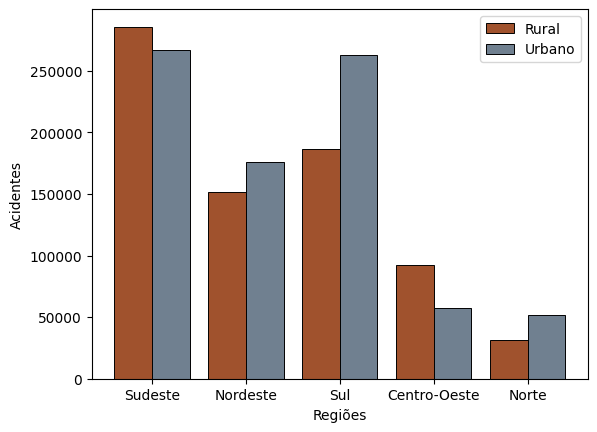

In [141]:
a = df.groupby(['regiao', 'uso_solo'])['regiao'].count()

r = list(df['regiao'].unique())

rrl = []
urb = []

for i in r:
    rrl.append(a[i]['Rural'])
    urb.append(a[i]['Urbano'])

l = len(r)

plt.bar(np.arange(len(r))-0.2, rrl, width=0.4, color='sienna',edgecolor='black', linewidth=0.7)
plt.bar(np.arange(len(r))+0.2, urb, width=0.4, color='slategrey', edgecolor='black', linewidth=0.7)

plt.xticks(np.arange(len(r)), labels=r)

plt.xlabel('Regiões')
plt.ylabel('Acidentes')

plt.legend(['Rural', 'Urbano'])

plt.show()


- Quais são as 10 causas mais frequentes de acidentes no Brasil?

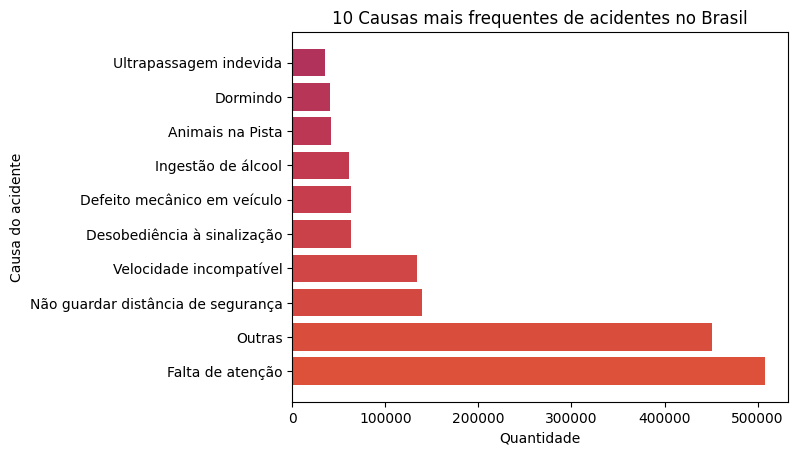

In [ ]:
a = df.groupby(['causa_acidente'])['causa_acidente'].count().sort_values(ascending=False)[:10]

plt.barh(a.index, a.values, align='center', color=color)
plt.ylabel('Causa do acidente')
plt.xlabel('Quantidade')
plt.title('10 Causas mais frequentes de acidentes no Brasil')
plt.show()

- Quais causas estão associadas à maior letalidade?

In [25]:
#df.groupby(['causa_acidente', 'mortos']).sum()

- A participação relativa de cada causa mudou ao longo dos anos?

In [ ]:
# TODO: Estudar forma de representar isso
df.groupby(['causa_acidente', 'ano'])[['causa_acidente']].count()
# vou ter que fazer um puta gráfico de barras aqui

causa_acidente
causa_acidente          ano                 
Animais na Pista        2007            4201
                        2008            4582
                        2009            4205
                        2010            4802
                        2011            5008
...                                      ...
Velocidade incompatível 2012           16829
                        2013           18694
                        2014           17715
                        2015           14259
                        2016           12322

[110 rows x 1 columns]

- Existe associação entre causa do acidente e tipo de pista ou traçado da via?

In [27]:
df.columns

Index(['data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio',
       'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia',
       'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via',
       'uso_solo', 'ano', 'pessoas', 'mortos', 'feridos_leves',
       'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'mes',
       'ano_mes', 'horas', 'dia', 'regiao'],
      dtype='str')

In [28]:
# TODO: Estudar forma de representar isso, e se isso está bom
df.groupby(['causa_acidente', 'tipo_pista', 'tracado_via'])[['causa_acidente']].count()

causa_acidente
causa_acidente          tipo_pista tracado_via                
Animais na Pista        Dupla      Cruzamento               54
                                   Curva                  1022
                                   Reta                   7904
                        Múltipla   Cruzamento               13
                                   Curva                    38
...                                                        ...
Velocidade incompatível Múltipla   Curva                  1911
                                   Reta                   2831
                        Simples    Cruzamento             2315
                                   Curva                 47249
                                   Reta                  21956

[99 rows x 1 columns]

- Qual a proporção entre acidentes sem vítimas, com feridos e com mortos?

In [29]:
# proporção seria 

- A relação entre feridos leves e graves varia conforme o tipo de acidente?

In [30]:
df.groupby(['tipo_acidente', 'feridos_graves', 'feridos_leves'])[['tipo_acidente']].count()

tipo_acidente
tipo_acidente           feridos_graves feridos_leves               
Atropelamento de animal 0              0                      26270
                                       1                       4880
                                       2                       1373
                                       3                        214
                                       4                        103
...                                                             ...
Tombamento              16             10                         1
                        18             17                         1
                        20             21                         1
                        21             2                          1
                        39             0                          1

[1569 rows x 1 columns]

- Quais variáveis têm maior correlação com o número de mortos por acidente?

- Acidentes com mais veículos envolvidos resultam proporcionalmente em mais mortes?

In [31]:
df.groupby(['veiculos'])[['mortos']].sum()

,mortos
veiculos,
1,28446
2,39497
3,6705
4,1400
5,443
6,164
7,76
8,44
9,25


- Acidentes em chuva são mais graves do que em tempo claro?

In [32]:
# Vai ter que ter a frequência relativa, só isso não é suficiente para comparar
t = (df.groupby(['condicao_metereologica', 'classificacao_acidente'])[['classificacao_acidente']].count())
print(t.loc['Ceu Claro'].sum())
print(t.loc['Chuva'].sum())

classificacao_acidente    753511
dtype: int64
classificacao_acidente    271324
dtype: int64


- A condição meteorológica influencia o tipo de acidente mais frequente?


In [33]:
df['tipo_acidente'].unique()

<ArrowStringArray>
[                            'Saída de Pista',
                    'Atropelamento de animal',
                                'Capotamento',
                            'Colisão lateral',
                    'Atropelamento de pessoa',
                           'Colisão traseira',
                        'Colisão Transversal',
                                 'Tombamento',
                    'Colisão com objeto fixo',
                            'Danos Eventuais',
 'Queda de motocicleta / bicicleta / veículo',
                      'Derramamento de Carga',
                      'Colisão com bicicleta',
                   'Colisão com objeto móvel',
                            'Colisão frontal',
                                   'Incêndio']
Length: 16, dtype: str

In [34]:
df.groupby(['condicao_metereologica', 'tipo_acidente'])[['tipo_acidente']].count()

tipo_acidente
condicao_metereologica tipo_acidente                                            
Ceu Claro              Atropelamento de animal                             22445
                       Atropelamento de pessoa                             25203
                       Capotamento                                         31777
                       Colisão Transversal                                 82147
                       Colisão com bicicleta                               10929
...                                                                          ...
Vento                  Derramamento de Carga                                  25
                       Incêndio                                               29
                       Queda de motocicleta / bicicleta / veículo            172
                       Saída de Pista                                        532
                       Tombamento                                            241

[139 rows x 1 columns]

- Qual tipo de pista concentra mais acidentes fatais?


In [35]:
df.groupby(['tipo_pista', 'classificacao_acidente'])[['classificacao_acidente']].count()

classificacao_acidente
tipo_pista classificacao_acidente                        
Dupla      Com Vítimas Fatais                       15843
           Com Vítimas Feridas                     212629
           Ignorado                                  5035
           Sem Vítimas                             392007
Múltipla   Com Vítimas Fatais                        2228
           Com Vítimas Feridas                      35709
           Ignorado                                   731
           Sem Vítimas                              79449
Simples    Com Vítimas Fatais                       44776
           Com Vítimas Feridas                     331986
           Ignorado                                  5894
           Sem Vítimas                             435747

- O traçado da via influencia a gravidade dos acidentes?


In [36]:
df.groupby(['tracado_via', 'classificacao_acidente'])[['classificacao_acidente']].count()

classificacao_acidente
tracado_via classificacao_acidente                        
Cruzamento  Com Vítimas Fatais                        1489
            Com Vítimas Feridas                      38502
            Ignorado                                   402
            Sem Vítimas                              61521
Curva       Com Vítimas Fatais                       14947
            Com Vítimas Feridas                     128631
            Ignorado                                  3166
            Sem Vítimas                             190920
Reta        Com Vítimas Fatais                       46411
            Com Vítimas Feridas                     413191
            Ignorado                                  8092
            Sem Vítimas                             654762

- Existe um perfil de risco combinando tipo de pista, traçado e condição meteorológica?


In [37]:
df.groupby(['tracado_via', 'classificacao_acidente', 'condicao_metereologica'])[['classificacao_acidente']].count()

classificacao_acidente
tracado_via classificacao_acidente condicao_metereologica                        
Cruzamento  Com Vítimas Fatais     Ceu Claro                                  841
                                   Chuva                                      108
                                   Ignorada                                    30
                                   Nevoeiro/neblina                            30
                                   Nublado                                    290
...                                                                           ...
Reta        Sem Vítimas            Neve                                        39
                                   Nevoeiro/neblina                          5799
                                   Nublado                                 117950
                                   Sol                                      95416
                                   Vento                                     1732

[100 rows x 1 columns]

- O perfil de causas de acidentes mudou entre o início e o fim do período analisado?


In [38]:
df.groupby(['tipo_acidente', 'ano'])[['tipo_acidente']].count()

tipo_acidente
tipo_acidente           ano                
Atropelamento de animal 2007           3556
                        2008           3868
                        2009           3712
                        2010           4250
                        2011           4446
...                                     ...
Tombamento              2012           7242
                        2013           6981
                        2014           6808
                        2015           5630
                        2016           5080

[160 rows x 1 columns]

- A letalidade dos acidentes melhorou ao longo do tempo em cada UF?


In [39]:
df.groupby(['uf', 'ano'])[['mortos']].sum()

mortos
uf ano         
AC 2007      20
   2008      13
   2009      31
   2010      14
   2011      23
...         ...
TO 2012     114
   2013     110
   2014     117
   2015      93
   2016     109

[270 rows x 1 columns]

- Existem picos atípicos de acidentes em datas específicas como feriados e carnaval?


In [40]:
# temos, mas como podemos mostrar isso ? além da questão da série temporal

- É possível segmentar os acidentes em grupos com perfis distintos de risco?

In [41]:
# usar algum método de clusterização 


- Quais UFs apresentam comportamento atípico em relação à média nacional de fatalidade?

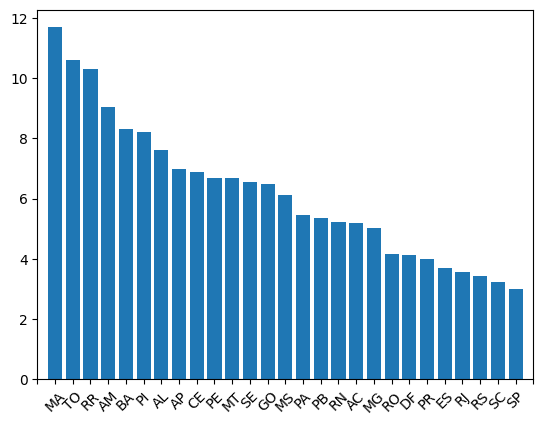

In [42]:
a = (df.groupby(['uf'])['mortos'].mean()*100).round(2).sort_values(ascending=False)

fig, ax = plt.subplots()

ax.bar(a.index, a.values, linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(-1, len(a.index)+1))

ax.tick_params("x", rotation=45)

plt.show()
